# 21. U-Net 간단 실습

이 노트북은 `20_U-Net_구조_파악.ipynb` 다음 단계로, 작은 합성 데이터셋을 사용해 binary segmentation을 실습합니다.

실제 segmentation 데이터셋은 이미지와 mask pair가 필요합니다. 여기서는 원 또는 사각형이 들어 있는 작은 이미지를 직접 만들고, 그 도형 영역을 mask로 예측하는 간단한 문제를 구성합니다.

이번 노트북의 목표는 다음과 같습니다.

- image-mask pair가 segmentation 학습의 기본 단위임을 확인합니다.
- 작은 U-Net 형태의 모델을 정의합니다.
- binary mask 예측을 위한 loss와 출력 형태를 이해합니다.
- 예측 mask를 시각화해 segmentation 결과를 읽습니다.


## 21-1. 준비

이 실습은 PyTorch를 사용합니다. GPU가 없어도 실행되도록 작은 합성 데이터와 작은 모델을 사용합니다.


In [1]:
import random

import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.unicode_minus'] = False

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


device: cuda


## 21-2. 합성 image-mask pair 만들기

Segmentation 데이터셋의 한 샘플은 보통 이미지와 mask가 한 쌍입니다.

- image: 모델 입력
- mask: 각 픽셀이 객체인지 배경인지 알려주는 정답

여기서는 배경 위에 밝은 원 하나를 그리고, 원 내부를 `1`, 배경을 `0`으로 하는 binary mask를 만듭니다.


In [2]:
def make_circle_sample(size=64):
    yy, xx = np.mgrid[:size, :size]
    cx = np.random.randint(16, size - 16)
    cy = np.random.randint(16, size - 16)
    radius = np.random.randint(7, 15)

    mask = ((xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2).astype(np.float32)
    image = np.random.normal(loc=0.15, scale=0.05, size=(size, size)).astype(np.float32)
    image += mask * np.random.uniform(0.55, 0.85)
    image = np.clip(image, 0.0, 1.0)

    return image, mask


def make_dataset(n_samples=160, size=64):
    images, masks = [], []
    for _ in range(n_samples):
        image, mask = make_circle_sample(size)
        images.append(image[None, :, :])
        masks.append(mask[None, :, :])

    images = torch.tensor(np.stack(images), dtype=torch.float32)
    masks = torch.tensor(np.stack(masks), dtype=torch.float32)
    return images, masks


images, masks = make_dataset()
print('images:', images.shape)
print('masks:', masks.shape)


images: torch.Size([160, 1, 64, 64])
masks: torch.Size([160, 1, 64, 64])


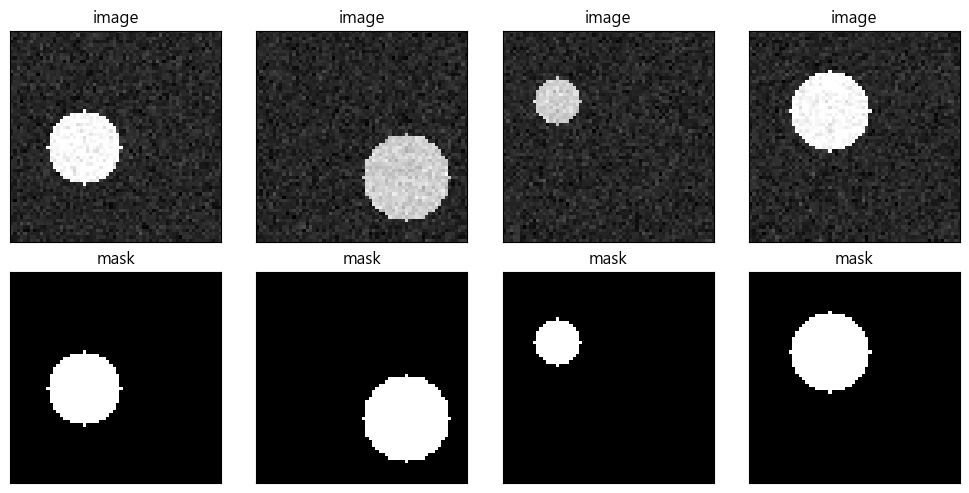

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(4):
    axes[0, i].imshow(images[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title('image')
    axes[1, i].imshow(masks[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('mask')
    for ax in axes[:, i]:
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()


## 21-3. 작은 U-Net 모델 정의

아래 모델은 실습용으로 줄인 U-Net입니다. 핵심은 encoder에서 feature를 저장해 두었다가 decoder에서 concatenate한다는 점입니다.

출력 채널은 1개입니다. 각 픽셀에 대해 객체일 logit을 하나씩 출력하고, sigmoid를 통과시키면 `0~1` 사이의 mask 확률이 됩니다.


In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(1, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(32, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(64, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(32, 16)
        self.out = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.out(d1)


model = TinyUNet().to(device)
sample_logits = model(images[:2].to(device))
print('input shape:', images[:2].shape)
print('output logits shape:', sample_logits.shape)


input shape: torch.Size([2, 1, 64, 64])
output logits shape: torch.Size([2, 1, 64, 64])


## 21-4. Loss와 학습

Binary segmentation에서는 각 픽셀을 배경 또는 객체로 분류합니다. PyTorch에서는 sigmoid와 binary cross entropy를 안정적으로 함께 계산하는 `BCEWithLogitsLoss`를 자주 사용합니다.


In [5]:
dataset = TensorDataset(images, masks)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_history = []
model.train()
for epoch in range(5):
    total_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    avg_loss = total_loss / len(dataset)
    loss_history.append(avg_loss)
    print(f'epoch {epoch + 1}: loss={avg_loss:.4f}')


epoch 1: loss=0.7413
epoch 2: loss=0.3799
epoch 3: loss=0.1394
epoch 4: loss=0.0677
epoch 5: loss=0.0529


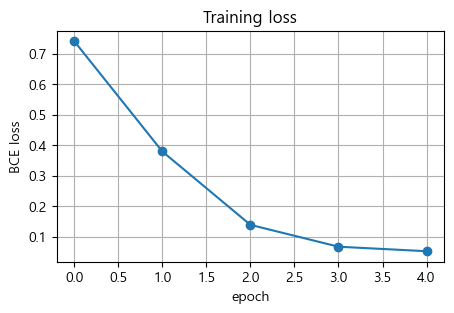

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(loss_history, marker='o')
plt.title('Training loss')
plt.xlabel('epoch')
plt.ylabel('BCE loss')
plt.grid(True)
plt.show()


## 21-5. 예측 mask 시각화

모델 출력 logits에 sigmoid를 적용하면 각 픽셀이 객체일 확률이 됩니다. 보통 threshold를 적용해 binary mask로 바꿉니다.


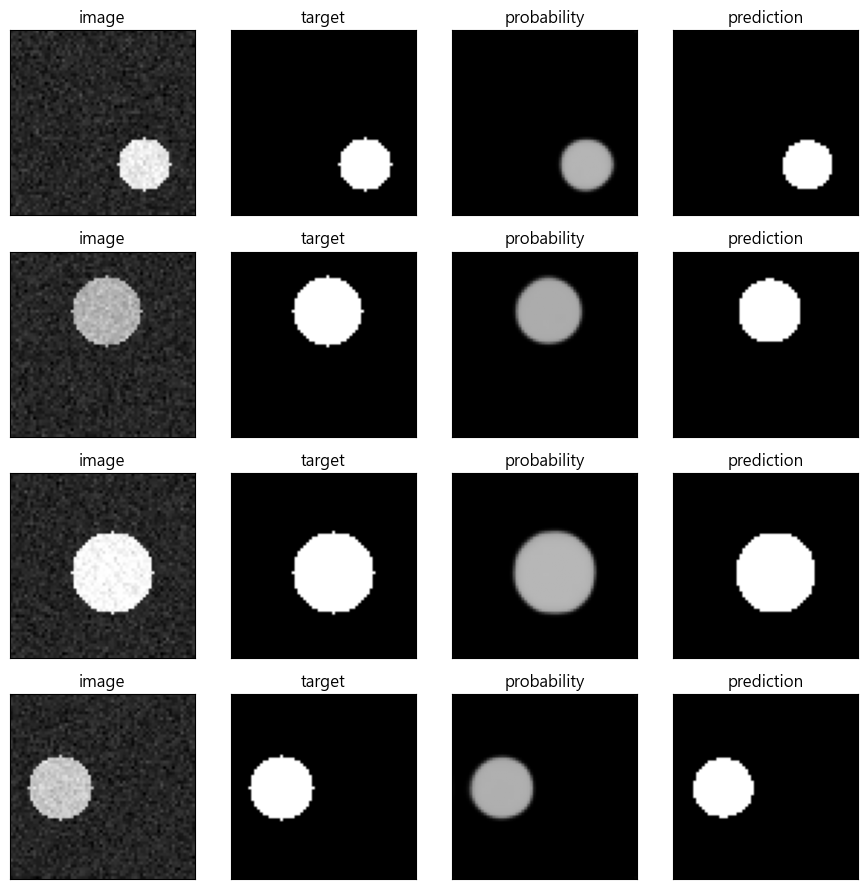

In [7]:
model.eval()
with torch.no_grad():
    test_images, test_masks = make_dataset(n_samples=4)
    logits = model(test_images.to(device))
    probs = torch.sigmoid(logits).cpu()
    pred_masks = (probs > 0.5).float()

fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for i in range(4):
    axes[i, 0].imshow(test_images[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title('image')
    axes[i, 1].imshow(test_masks[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title('target')
    axes[i, 2].imshow(probs[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title('probability')
    axes[i, 3].imshow(pred_masks[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 3].set_title('prediction')
    for ax in axes[i]:
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()


## 21-6. 간단한 IoU 계산

Segmentation에서는 예측 mask와 정답 mask가 얼마나 겹치는지 IoU로 평가할 수 있습니다. Detection의 bounding box IoU와 아이디어는 같지만, 여기서는 픽셀 mask의 교집합과 합집합을 계산합니다.


In [8]:
def mask_iou(pred, target, eps=1e-7):
    pred = pred.bool()
    target = target.bool()
    intersection = (pred & target).sum(dim=(1, 2, 3)).float()
    union = (pred | target).sum(dim=(1, 2, 3)).float()
    return (intersection + eps) / (union + eps)


ious = mask_iou(pred_masks, test_masks)
print('sample IoU:', ious.numpy())
print('mean IoU:', ious.mean().item())


sample IoU: [0.92885375 0.8526077  0.9836868  0.8965517 ]
mean IoU: 0.9154249429702759


## 21-7. 정리

- Segmentation 학습 데이터는 image와 mask가 쌍으로 구성됩니다.
- Binary segmentation 모델은 보통 픽셀마다 logit 하나를 출력합니다.
- `BCEWithLogitsLoss`는 binary mask 예측에 자주 쓰이는 손실 함수입니다.
- U-Net의 skip connection은 decoder가 경계와 위치 정보를 복원하는 데 도움을 줍니다.
- Mask IoU는 예측 mask와 정답 mask의 픽셀 단위 겹침 정도를 평가합니다.
- 다음 노트북에서는 semantic segmentation과 instance segmentation의 차이를 정리합니다.
